In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import AnyMessage, add_messages

from dataclasses import dataclass
from typing import Annotated, List

from langchain_groq import ChatGroq
from IPython.display import display, Image

from langgraph.prebuilt import ToolNode, tools_condition

from pprint import pprint


c:\Users\Kunal\OneDrive\RAG\project_langgrapth\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
@dataclass
class MyMultiToolBot:
    messages: Annotated[List[AnyMessage],add_messages]

In [3]:
def addNumber(a: float, b: float) -> float:

    """ 
    Function is used to Sum two given Numbers
        :param a: First Argument to Perform Addition
        :type a: float

        :param b: Second Argument to Perform Addition
        :type b: float

        :returns : Sum of Given Arguments a and b
        :rtype : float

        .. code-block :: python
            #Example
            >>> addNumber(2.1,3.5)
            5.6

            >>> addNumber(3,4)
            7.0
    """

    return a + b 

def subNumber(a: float, b: float) -> float:

    """ 
    Function is used to Subtract two given Numbers. Subtract parameter b from a
        :param a: First Argument to Perform Subtraction
        :type a: float

        :param b: Second Argument to Perform Subtraction
        :type b: float

        :returns : Subtract b from a
        :rtype : float

        .. code-block :: python
            #Example
            >>> subNumber(2.1,3.5)
            -1.4

            >>> subNumber(3,4)
            -1.0
    """

    return a - b 


def mulNumber(a: float, b: float) -> float:

    """ 
    Function is used to Multiply two given Numbers. 
        :param a: First Argument to Perform Multiplication
        :type a: float

        :param b: Second Argument to Perform Multiplication
        :type b: float

        :returns : multiply a and b
        :rtype : float

        .. code-block :: python
            #Example
            >>> subNumber(2.1,3.5)
            7.35

            >>> subNumber(3,4)
            12.0
    """

    return a * b 

In [4]:
llm = ChatGroq(model = "openai/gpt-oss-120b")
llm_bind = llm.bind_tools([mulNumber, subNumber, addNumber])


In [5]:
llm_bind.invoke("Please Add and Multiply 4 and 3")

AIMessage(content='', additional_kwargs={'reasoning_content': "We need to add and multiply 4 and 3. Use addNumber and mulNumber functions. Compute sum = 7, product = 12. Return both results. We'll call functions.", 'tool_calls': [{'id': 'fc_cc87a6c0-c498-4c30-9e3c-678eb35e0732', 'function': {'arguments': '{"a":4,"b":3}', 'name': 'addNumber'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 502, 'total_tokens': 576, 'completion_time': 0.170417292, 'completion_tokens_details': {'reasoning_tokens': 40}, 'prompt_time': 0.023513235, 'prompt_tokens_details': None, 'queue_time': 0.004150395, 'total_time': 0.193930527}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8c2cca97f9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--23faa8d4-aed4-45a6-9a6f-6f08fa8f803e-0', tool_calls=[{'name': 'addNumber', 'args': {'a': 4, 'b': 3}, 'id': 'fc_cc87a6c0-c498-4c30-9e3c-

In [6]:
def llm_tools(state: MyMultiToolBot):

    return {"messages": llm_bind.invoke(state.messages)}

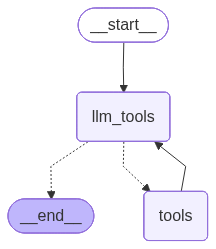

In [7]:
graph = StateGraph(MyMultiToolBot)

graph.add_node("llm_tools",llm_tools)
graph.add_node("tools", ToolNode([mulNumber, subNumber, addNumber]))


graph.add_edge(START,"llm_tools")
graph.add_conditional_edges("llm_tools", tools_condition)
graph.add_edge("tools", "llm_tools")
graph.add_edge("llm_tools", END)

graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [9]:
msg = graph_builder.invoke({"messages": "add, subtract and multiply Number 4 and 3"})

for item in msg['messages']:
    item.pretty_print()

================================ Human Message =================================

add, subtract and multiply Number 4 and 3
================================== Ai Message ==================================
Tool Calls:
  addNumber (fc_140a44f6-7c2d-4331-83bb-96c337206c64)
 Call ID: fc_140a44f6-7c2d-4331-83bb-96c337206c64
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: addNumber

7.0
================================== Ai Message ==================================
Tool Calls:
  subNumber (fc_cee1d99d-3b8f-4db7-8d0a-c57d8af35182)
 Call ID: fc_cee1d99d-3b8f-4db7-8d0a-c57d8af35182
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: subNumber

1.0
================================== Ai Message ==================================
Tool Calls:
  mulNumber (fc_3c72103b-f57e-4f98-a87f-d58f11dab218)
 Call ID: fc_3c72103b-f57e-4f98-a87f-d58f11dab218
  Args:
    a: 4
    b: 3
===